# Prevalencia de Desnutrición Crónica Infantil en el Perú

Este cuaderno de notas sirve para explorar de forma visual e interactiva la evolución de los indicadores nutricionales infantiles utilizando los datos de la **ENDES (INEI)**.

In [1]:
# Habilitar auto-recarga del módulo en caso de que edites indicadores.py
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mnp.utils.indicators import calculate_chronic_malnutrition
from mnp.loader import get_available_years

2026-05-24 23:00:45.151 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


## 1. Calcular la Prevalencia Histórica de Desnutrición Crónica

Ejecutamos la función de cálculo del indicador importada desde `mnp.utils.indicators` para cada uno de los años de la encuesta ENDES que tienes descargados localmente en `data/raw`:

In [2]:
# 1. Obtener los años disponibles localmente
years = get_available_years()
print(f"Años detectados localmente: {sorted(years)}")

results = []

# 2. Calcular los indicadores para cada año de forma secuencial
for y in sorted(years):
    try:
        df_y = calculate_chronic_malnutrition(y)
        results.append(df_y)
    except Exception as e:
        print(f"❌ No se pudo procesar el año {y}: {e}")

# 3. Unificar los resultados en una única tabla de tendencia
df_prevalencia = pd.concat(results, ignore_index=True)
df_prevalencia

Años detectados localmente: [1996, 2000, 2004, 2005, 2006, 2007, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
2026-05-24 23:01:07.819 | INFO     | mnp.indicators:calculate_chronic_malnutrition:34 - 🚀 Calculando Desnutrición Crónica para el año 1996...
❌ No se pudo procesar el año 1996: Se encontró el módulo anthropometry pero no el registro rech6 (alias: rech6) para el año 1996
2026-05-24 23:01:07.872 | INFO     | mnp.indicators:calculate_chronic_malnutrition:34 - 🚀 Calculando Desnutrición Crónica para el año 2000...
❌ No se pudo procesar el año 2000: Se encontró el módulo anthropometry pero no el registro rech6 (alias: rech6) para el año 2000
2026-05-24 23:01:07.877 | INFO     | mnp.indicators:calculate_chronic_malnutrition:34 - 🚀 Calculando Desnutrición Crónica para el año 2004...
❌ No se pudo procesar el año 2004: No se encontró el módulo anthropometry (alias: anthropometry) para el año 2004
2026-05-24 23:01:07.881 | INFO     | mnp.

,Anio,Casos_Muestra,Porcentaje_DC
0,2007,4961,29.20
1,2009,9782,23.82
2,2010,9219,23.26
3,2011,9184,19.53
4,2012,9662,18.12
5,2013,8999,17.49
6,2014,9614,14.56
7,2015,24070,14.44
8,2016,21250,13.13
9,2017,21534,12.88


## 2. Gráfico de Evolución Temporal (Prevalencia %)

Ahora que tenemos los datos calculados de forma limpia, usamos `seaborn` y `matplotlib` para graficar la curva de tendencia histórica de la desnutrición crónica infantil en el Perú:

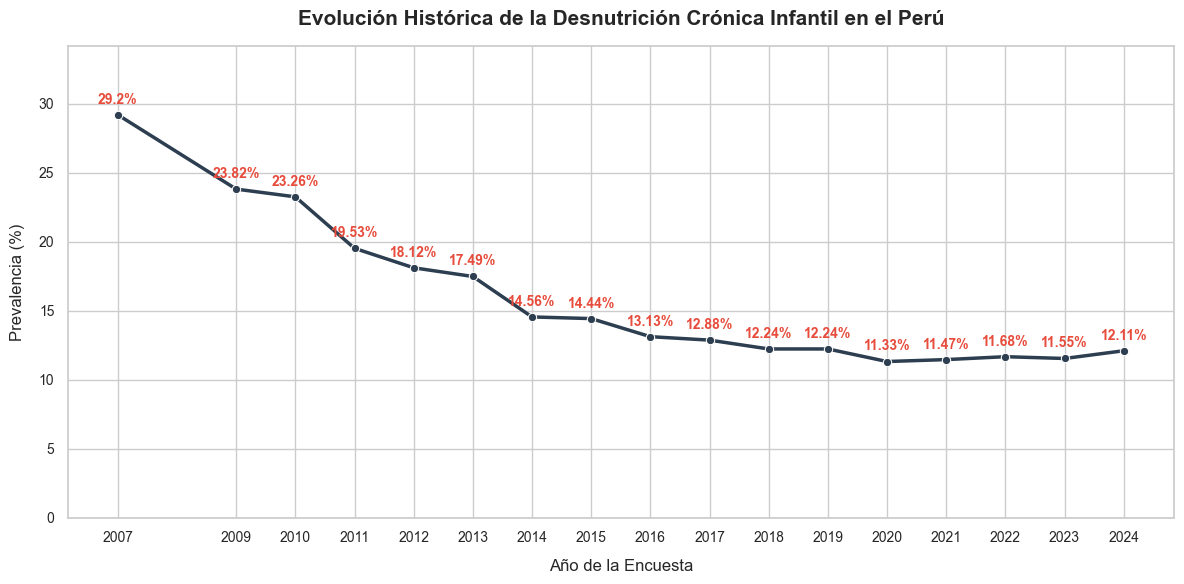

In [3]:
# Configurar estilo estético del gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Graficar curva y puntos
sns.lineplot(data=df_prevalencia, x="Anio", y="Porcentaje_DC", marker="o", linewidth=2.5, color="#2c3e50")

# Títulos y etiquetas
plt.title("Evolución Histórica de la Desnutrición Crónica Infantil en el Perú", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Año de la Encuesta", fontsize=12, labelpad=10)
plt.ylabel("Prevalencia (%)", fontsize=12, labelpad=10)
plt.xticks(df_prevalencia["Anio"].unique(), fontsize=10)
plt.yticks(fontsize=10)

# Añadir etiquetas con el porcentaje exacto encima de cada punto del gráfico
for i, row in df_prevalencia.iterrows():
    plt.text(
        row["Anio"], 
        row["Porcentaje_DC"] + 0.8, 
        f"{row['Porcentaje_DC']}%", 
        ha="center", 
        fontsize=10, 
        fontweight="semibold",
        color="#e74c3c"
    )

# Ajustar límites de visualización
plt.ylim(0, df_prevalencia["Porcentaje_DC"].max() + 5)
plt.tight_layout()

# Mostrar el gráfico final
plt.show()